In [1]:
import pandas as pd 

df = pd.read_csv('sentiment_analysis_results_20250929_103309.csv')

In [5]:
df[df['Model'] == 'OpenAI']['Model'] = 'gpt-4.1'

/var/folders/ks/w4d6mxgj70g70pk9xdq5l92m0000gn/T/ipykernel_35803/745699925.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['Model'] == 'OpenAI']['Model'] = 'gpt-4.1'


In [6]:
df_gpt5 = pd.read_csv('gpt51_sentiment_analysis_results_20251003_090847.csv')

In [7]:
df_full = pd.concat([df, df_gpt5])

In [18]:
pivot_df.to_csv('5models_confirmityScores.csv', index=True)

In [14]:
conformity_scores = calculate_conformity_score_wide(pivot_df)

# Add to your DataFrame
pivot_df['Conformity_Score'] = conformity_scores

In [12]:
pivot_df = df_full.pivot(index=['Document_ID', 'Project_Name'], columns='Model', values=['Recommendation'])

In [13]:
def calculate_conformity_score_wide(pivot_df):
    """
    Calculate conformity score for each project across all models (wide format)
    
    Conformity score = (Number of models agreeing with majority) / (Total number of models) * 100
    
    Returns: Series with conformity scores for each project
    """
    def calculate_for_row(row):
        # Get all recommendations for this project
        recommendations = row.values
        
        # Count occurrences of each recommendation
        from collections import Counter
        counts = Counter(recommendations)
        
        # Find the maximum count (most common recommendation)
        max_count = max(counts.values())
        
        # Calculate conformity score as percentage
        return (max_count / len(recommendations)) * 100
    
    # Apply to each row
    conformity_scores = pivot_df.apply(calculate_for_row, axis=1)
    return conformity_scores

In [38]:
df.columns

Index(['Project_Name', 'Document_ID', 'Error', 'Model', 'Recommendation',
       'Recommendation_Reasoning', 'Input_Tokens', 'Output_Tokens',
       'Input_Cost', 'Output_Cost', 'Total_Cost'],
      dtype='object')

In [40]:
def calculate_average_costs_per_model(df):
    """
    Calculate average costs per model (long format)
    
    Returns: DataFrame with average costs for each model
    """
    # Group by Model and calculate means
    cost_stats = df.groupby('Model').agg({
        'Input_Cost': 'mean',
        'Output_Cost': 'mean', 
        'Total_Cost': 'mean',
        'Input_Tokens': 'mean',
        'Output_Tokens': 'mean'
    }).round(6)  # Round to 6 decimal places for costs
    
    return cost_stats

In [42]:
cost_stats = calculate_average_costs_per_model(df)

In [43]:
cost_stats

,Input_Cost,Output_Cost,Total_Cost,Input_Tokens,Output_Tokens
Model,,,,,
claude-opus-4-1-20250805,0.113911,0.015207,0.129118,7594.08,202.76
claude-sonnet-4-5,0.022782,0.003532,0.026314,7594.08,235.48
gemini-2.5-flash-lite,0.000790,0.000055,0.000846,7904.74,138.10
gemini-2.5-pro,0.009881,0.001217,0.011098,7904.74,121.70
gpt-4.1,0.019251,0.001829,0.021080,6416.90,152.42
gpt-5-2025-08-07,0.008020,0.010608,0.018627,6415.90,1060.76
gpt-5-mini-2025-08-07,0.001604,0.001358,0.002962,6415.90,679.24
mistral-large-latest,0.014251,0.004751,0.019002,7125.46,791.88


In [50]:
def analyze_sentiment_disagreement_patterns_8models_wide(df):
    """
    Analyze sentiment disagreement patterns for 8 models (wide format)
    
    Returns: DataFrame with sentiment disagreement pattern analysis
    """
    models = ['claude-opus-4-1-20250805', 'claude-sonnet-4-5', 'gemini-2.5-flash-lite', 
              'gemini-2.5-pro', 'gpt-4.1', 'gpt-5-2025-08-07', 'gpt-5-mini-2025-08-07', 
              'mistral-large-latest']
    
    # Initialize counters for different disagreement types
    disagreement_patterns = {
        'Complete Agreement': 0,
        'Negative vs Neutral': 0,
        'Positive vs Neutral': 0,
        'Positive vs Negative': 0,
        'Mixed (3 sentiments)': 0,
        'Mixed (4 sentiments)': 0,
        'Mixed (5 sentiments)': 0,
        'Mixed (6 sentiments)': 0,
        'Mixed (7 sentiments)': 0,
        'Mixed (8 sentiments)': 0
    }
    
    for idx, row in df.iterrows():
        recommendations = [row[('Recommendation', model)] for model in models]
        unique_sentiments = list(set(recommendations))
        sentiment_counts = pd.Series(recommendations).value_counts()
        
        # Determine disagreement type based on unique sentiments
        if len(unique_sentiments) == 1:
            disagreement_patterns['Complete Agreement'] += 1
        elif len(unique_sentiments) == 2:
            # For 2-way disagreements, check which sentiments are involved
            sent1, sent2 = sorted(unique_sentiments)
            
            if sent1 == 'Negative' and sent2 == 'Neutral':
                disagreement_patterns['Negative vs Neutral'] += 1
            elif sent1 == 'Neutral' and sent2 == 'Positive':
                disagreement_patterns['Positive vs Neutral'] += 1
            elif sent1 == 'Negative' and sent2 == 'Positive':
                disagreement_patterns['Positive vs Negative'] += 1
            else:
                # Handle other 2-way combinations
                pattern_name = f'{sent1} vs {sent2}'
                if pattern_name not in disagreement_patterns:
                    disagreement_patterns[pattern_name] = 0
                disagreement_patterns[pattern_name] += 1
        elif len(unique_sentiments) == 3:
            disagreement_patterns['Mixed (3 sentiments)'] += 1
        elif len(unique_sentiments) == 4:
            disagreement_patterns['Mixed (4 sentiments)'] += 1
        elif len(unique_sentiments) == 5:
            disagreement_patterns['Mixed (5 sentiments)'] += 1
        elif len(unique_sentiments) == 6:
            disagreement_patterns['Mixed (6 sentiments)'] += 1
        elif len(unique_sentiments) == 7:
            disagreement_patterns['Mixed (7 sentiments)'] += 1
        else:  # 8 different sentiments
            disagreement_patterns['Mixed (8 sentiments)'] += 1
    
    # Convert to DataFrame
    total_projects = len(df)
    results = []
    
    for pattern, count in disagreement_patterns.items():
        if count > 0:  # Only include patterns that actually occurred
            percentage = (count / total_projects) * 100
            results.append({
                'Pattern': pattern,
                'Count': count,
                'Percentage': f"{percentage:.1f}%"
            })
    
    return pd.DataFrame(results)

In [51]:
patterns = analyze_sentiment_disagreement_patterns_8models_wide(df)
patterns

,Pattern,Count,Percentage
0,Complete Agreement,24,48.0%
1,Negative vs Neutral,11,22.0%
2,Positive vs Neutral,13,26.0%
3,Mixed (3 sentiments),2,4.0%


In [48]:
df = df.pivot(index=['Document_ID', 'Project_Name'], columns='Model', values=['Recommendation', 'Recommendation_Reasoning'])

In [49]:
df.columns

MultiIndex([(          'Recommendation', 'claude-opus-4-1-20250805'),
            (          'Recommendation',        'claude-sonnet-4-5'),
            (          'Recommendation',    'gemini-2.5-flash-lite'),
            (          'Recommendation',           'gemini-2.5-pro'),
            (          'Recommendation',                  'gpt-4.1'),
            (          'Recommendation',         'gpt-5-2025-08-07'),
            (          'Recommendation',    'gpt-5-mini-2025-08-07'),
            (          'Recommendation',     'mistral-large-latest'),
            ('Recommendation_Reasoning', 'claude-opus-4-1-20250805'),
            ('Recommendation_Reasoning',        'claude-sonnet-4-5'),
            ('Recommendation_Reasoning',    'gemini-2.5-flash-lite'),
            ('Recommendation_Reasoning',           'gemini-2.5-pro'),
            ('Recommendation_Reasoning',                  'gpt-4.1'),
            ('Recommendation_Reasoning',         'gpt-5-2025-08-07'),
            ('Recomm

In [7]:
df.head()

Recommendation  \
Model                                                          claude-opus-4-1-20250805   
Document_ID Project_Name                                                                  
1.001       Hodnota za peniaze v nákupe rýchlikových vozňov...                 Negative   
1.012       Modernizácia elektronickej komunikačnej siete ŽSR                  Negative   
1.014       ŽSR, Elektrifikácia trate Haniska – Veľká Ida –...                 Negative   
1.036       Modernizácia vozového parku ZSSK časti 6 a 7                       Negative   
1.045       D1 Lietavská Lúčka – Dubná Skala, technológia t...                 Positive   

                                                                                  \
Model                                                          claude-sonnet-4-5   
Document_ID Project_Name                                                           
1.001       Hodnota za peniaze v nákupe rýchlikových vozňov...           Neutral   
1.012       Modernizácia elektronickej komunikačnej siete ŽSR           Negative   
1.014       ŽSR, Elektrifikácia trate Haniska – Veľká Ida –...          Negative   
1.036       Modernizácia vozového parku ZSSK časti 6 a 7                Negative   
1.045       D1 Lietavská Lúčka – Dubná Skala, technológia t...          Positive   

                                                                                      \
Model                                                          gemini-2.5-flash-lite   
Document_ID Project_Name                                                               
1.001       Hodnota za peniaze v nákupe rýchlikových vozňov...               Neutral   
1.012       Modernizácia elektronickej komunikačnej siete ŽSR                Neutral   
1.014       ŽSR, Elektrifikácia trate Haniska – Veľká Ida –...              Negative   
1.036       Modernizácia vozového parku ZSSK časti 6 a 7                    Negative   
1.045       D1 Lietavská Lúčka – Dubná Skala, technológia t...              Positive   

                                                                               \
Model                                                          gemini-2.5-pro   
Document_ID Project_Name                                                        
1.001       Hodnota za peniaze v nákupe rýchlikových vozňov...        Neutral   
1.012       Modernizácia elektronickej komunikačnej siete ŽSR         Neutral   
1.014       ŽSR, Elektrifikácia trate Haniska – Veľká Ida –...       Negative   
1.036       Modernizácia vozového parku ZSSK časti 6 a 7             Negative   
1.045       D1 Lietavská Lúčka – Dubná Skala, technológia t...       Positive   

                                                                          \
Model                                                            gpt-4.1   
Document_ID Project_Name                                                   
1.001       Hodnota za peniaze v nákupe rýchlikových vozňov...   Neutral   
1.012       Modernizácia elektronickej komunikačnej siete ŽSR    Neutral   
1.014       ŽSR, Elektrifikácia trate Haniska – Veľká Ida –...  Negative   
1.036       Modernizácia vozového parku ZSSK časti 6 a 7        Negative   
1.045       D1 Lietavská Lúčka – Dubná Skala, technológia t...  Positive   

                                                                                 \
Model                                                          gpt-5-2025-08-07   
Document_ID Project_Name                                                          
1.001       Hodnota za peniaze v nákupe rýchlikových vozňov...          Neutral   
1.012       Modernizácia elektronickej komunikačnej siete ŽSR           Neutral   
1.014       ŽSR, Elektrifikácia trate Haniska – Veľká Ida –...         Negative   
1.036       Modernizácia vozového parku ZSSK časti 6 a 7               Negative   
1.045       D1 Lietavská Lúčka – Dubná Skala, technológia t...         Positive   

                                           

In [8]:
def calculate_agreement_percentage_8models_wide(df):
    """
    Calculate agreement percentage for 8 models (wide format)
    
    This function calculates what percentage of models agree on the most common sentiment
    for each project. It looks at the Recommendation columns for all 8 models and finds
    the most frequent recommendation, then calculates its percentage.
    
    Returns: Series with agreement percentages for each project
    """
    models = ['claude-opus-4-1-20250805', 'claude-sonnet-4-5', 'gemini-2.5-flash-lite', 
              'gemini-2.5-pro', 'gpt-4.1', 'gpt-5-2025-08-07', 'gpt-5-mini-2025-08-07', 
              'mistral-large-latest']
    
    def calculate_for_row(row):
        recommendations = [row[('Recommendation', model)] for model in models]
        
        # Count occurrences of each recommendation
        from collections import Counter
        counts = Counter(recommendations)
        
        # Find the maximum count (most common recommendation)
        max_count = max(counts.values())
        
        # Calculate percentage as (max_count / total_models) * 100
        return (max_count / len(recommendations)) * 100
    
    # Apply to each row
    agreement_scores = df.apply(calculate_for_row, axis=1)
    return agreement_scores

In [ ]:
calculate_agreement_percentage_8models_wide(df)

In [18]:
find_model_outliers_8models_wide(df)

claude-opus-4-1-20250805    7
claude-sonnet-4-5           2
gemini-2.5-flash-lite       4
gemini-2.5-pro              5
gpt-4.1                     7
gpt-5-2025-08-07            7
gpt-5-mini-2025-08-07       9
mistral-large-latest        2
dtype: int64

In [22]:
def analyze_disagreement_patterns_8models_wide(df):
    """
    Analyze disagreement patterns for 8 models (wide format)
    
    Returns: DataFrame with pattern analysis
    """
    models = ['claude-opus-4-1-20250805', 'claude-sonnet-4-5', 'gemini-2.5-flash-lite', 
              'gemini-2.5-pro', 'gpt-4.1', 'gpt-5-2025-08-07', 'gpt-5-mini-2025-08-07', 
              'mistral-large-latest']
    
    patterns = {}
    
    for idx, row in df.iterrows():
        recommendations = [row[('Recommendation', model)] for model in models]
        counts = pd.Series(recommendations).value_counts()
        
        # Create pattern signature (e.g., "5-3" means 5 models agree, 3 disagree)
        pattern = '-'.join(map(str, sorted(counts.values, reverse=True)))
        patterns[pattern] = patterns.get(pattern, 0) + 1
    
    # Convert to DataFrame
    total_projects = len(df)
    results = []
    
    for pattern, count in sorted(patterns.items(), key=lambda x: x[1], reverse=True):
        percentage = (count / total_projects) * 100
        results.append({
            'Pattern': pattern,
            'Count': count,
            'Percentage': f"{percentage:.1f}%"
        })
    
    return pd.DataFrame(results)

In [23]:
patterns = analyze_disagreement_patterns_8models_wide(df)

In [25]:
patterns

,Pattern,Count,Percentage
0,8,24,48.0%
1,7-1,8,16.0%
2,5-3,7,14.0%
3,4-4,5,10.0%
4,6-2,4,8.0%
5,4-3-1,1,2.0%
6,6-1-1,1,2.0%


In [26]:
def calculate_recommendation_counts_per_model(df):
    """
    Calculate recommendation value counts for each model (wide format)
    
    Returns: DataFrame with recommendation counts for each model
    """
    models = ['claude-opus-4-1-20250805', 'claude-sonnet-4-5', 'gemini-2.5-flash-lite', 
              'gemini-2.5-pro', 'gpt-4.1', 'gpt-5-2025-08-07', 'gpt-5-mini-2025-08-07', 
              'mistral-large-latest']
    
    # Create a DataFrame to store the counts
    counts_df = pd.DataFrame()
    
    for model in models:
        # Get value counts for this model
        model_counts = df[('Recommendation', model)].value_counts()
        counts_df[model] = model_counts
    
    # Fill NaN values with 0 and convert to int
    counts_df = counts_df.fillna(0).astype(int)
    
    # Sort by index (recommendation type)
    counts_df = counts_df.sort_index()
    
    return counts_df

In [28]:
counts = calculate_recommendation_counts_per_model(df)
counts.T

"(Recommendation, claude-opus-4-1-20250805)",Negative,Neutral,Positive
claude-opus-4-1-20250805,16,13,21
claude-sonnet-4-5,12,17,21
gemini-2.5-flash-lite,7,21,22
gemini-2.5-pro,7,21,22
gpt-4.1,3,30,17
gpt-5-2025-08-07,3,26,21
gpt-5-mini-2025-08-07,7,12,31
mistral-large-latest,10,22,18


In [ ]:
def calculate_pairwise_disagreements_8models_wide(df):
    """
    Calculate pairwise disagreement rates for 8 models (wide format)
    
    This function creates a matrix showing the disagreement rate between each pair of models.
    It calculates what percentage of projects each model pair disagrees on.
    
    Returns: DataFrame matrix with disagreement percentages
    """
    models = ['claude-opus-4-1-20250805', 'claude-sonnet-4-5', 'gemini-2.5-flash-lite', 
              'gemini-2.5-pro', 'gpt-4.1', 'gpt-5-2025-08-07', 'gpt-5-mini-2025-08-07', 
              'mistral-large-latest']
    disagreement_matrix = pd.DataFrame(index=models, columns=models)
    
    for model1 in models:
        for model2 in models:
            if model1 != model2:
                disagreements = df[('Recommendation', model1)] != df[('Recommendation', model2)]
                disagreement_rate = disagreements.sum() / len(df) * 100
                disagreement_matrix.loc[model1, model2] = disagreement_rate
            else:
                disagreement_matrix.loc[model1, model2] = 0
    
    return disagreement_matrix

In [30]:
disagreement = calculate_pairwise_disagreements_8models_wide(df)
disagreement

,claude-opus-4-1-20250805,claude-sonnet-4-5,gemini-2.5-flash-lite,gemini-2.5-pro,gpt-4.1,gpt-5-2025-08-07,gpt-5-mini-2025-08-07,mistral-large-latest
claude-opus-4-1-20250805,0,12.0,20.0,24.0,38.0,38.0,34.0,22.0
claude-sonnet-4-5,12.0,0,16.0,20.0,26.0,26.0,28.0,10.0
gemini-2.5-flash-lite,20.0,16.0,0,20.0,22.0,22.0,22.0,22.0
gemini-2.5-pro,24.0,20.0,20.0,0,22.0,14.0,28.0,18.0
gpt-4.1,38.0,26.0,22.0,22.0,0,8.0,36.0,16.0
gpt-5-2025-08-07,38.0,26.0,22.0,14.0,8.0,0,28.0,20.0
gpt-5-mini-2025-08-07,34.0,28.0,22.0,28.0,36.0,28.0,0,30.0
mistral-large-latest,22.0,10.0,22.0,18.0,16.0,20.0,30.0,0


In [31]:
def calculate_deviation_scores_8models_wide(df):
    """
    Calculate how often each model deviates from the majority (8 models, wide format)
    
    This function calculates what percentage of projects each model disagrees with
    the most common recommendation (majority opinion).
    
    Returns: Series showing deviation percentage for each model
    """
    models = ['claude-opus-4-1-20250805', 'claude-sonnet-4-5', 'gemini-2.5-flash-lite', 
              'gemini-2.5-pro', 'gpt-4.1', 'gpt-5-2025-08-07', 'gpt-5-mini-2025-08-07', 
              'mistral-large-latest']
    deviation_scores = {}
    
    for model in models:
        deviations = 0
        for idx, row in df.iterrows():
            recommendations = [row[('Recommendation', m)] for m in models]
            counts = pd.Series(recommendations).value_counts()
            most_common = counts.index[0]
            
            if row[('Recommendation', model)] != most_common:
                deviations += 1
        
        deviation_scores[model] = deviations / len(df) * 100
    
    return pd.Series(deviation_scores)

In [33]:
deviation = calculate_deviation_scores_8models_wide(df)
deviation_df = pd.DataFrame(deviation)
deviation_df

,0
claude-opus-4-1-20250805,14.0
claude-sonnet-4-5,6.0
gemini-2.5-flash-lite,14.0
gemini-2.5-pro,14.0
gpt-4.1,24.0
gpt-5-2025-08-07,24.0
gpt-5-mini-2025-08-07,22.0
mistral-large-latest,8.0


In [34]:
def calculate_model_reliability_8models_wide(df):
    """
    Calculate reliability scores for 8 models (wide format)
    
    This function calculates how often each model agrees with other models across
    all projects. Higher scores indicate more reliable/consistent models.
    
    Returns: Series showing reliability percentage for each model (sorted descending)
    """
    models = ['claude-opus-4-1-20250805', 'claude-sonnet-4-5', 'gemini-2.5-flash-lite', 
              'gemini-2.5-pro', 'gpt-4.1', 'gpt-5-2025-08-07', 'gpt-5-mini-2025-08-07', 
              'mistral-large-latest']
    reliability_scores = {}
    
    for model in models:
        total_agreements = 0
        total_comparisons = 0
        
        for other_model in models:
            if other_model != model:
                agreements = df[('Recommendation', model)] == df[('Recommendation', other_model)]
                total_agreements += agreements.sum()
                total_comparisons += len(df)
        
        reliability_scores[model] = (total_agreements / total_comparisons) * 100
    
    return pd.Series(reliability_scores).sort_values(ascending=False)

In [36]:
reliability = calculate_model_reliability_8models_wide(df)
reliability_df = pd.DataFrame(reliability)
reliability_df

,0
claude-sonnet-4-5,80.285714
mistral-large-latest,80.285714
gemini-2.5-flash-lite,79.428571
gemini-2.5-pro,79.142857
gpt-5-2025-08-07,77.714286
gpt-4.1,76.000000
claude-opus-4-1-20250805,73.142857
gpt-5-mini-2025-08-07,70.571429


In [ ]:
# Fixed version of find_model_outliers function
def find_model_outliers(df):
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI']
    outlier_counts = {}
    
    for model in models:
        outliers = 0
        for idx, row in df.iterrows():
            recommendations = [row[('Recommendation', m)] for m in models]
            counts = pd.Series(recommendations).value_counts()
            
            # If this model's recommendation is in minority
            if counts[row[('Recommendation', model)]] < counts.max():
                outliers += 1
        
        outlier_counts[model] = outliers
    
    return pd.Series(outlier_counts)

# Run the analysis
outlier_results = find_model_outliers(df)
print("Number of times each model was in the minority:")
print(outlier_results)


In [ ]:
# Fixed version of analyze_disagreement_patterns function
def analyze_disagreement_patterns(df):
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI']
    
    # Create all possible disagreement patterns
    patterns = {}
    
    for idx, row in df.iterrows():
        recommendations = [row[('Recommendation', m)] for m in models]
        counts = pd.Series(recommendations).value_counts()
        
        # Create pattern signature (e.g., "3-1" means 3 models agree, 1 disagrees)
        pattern = '-'.join(map(str, sorted(counts.values, reverse=True)))
        patterns[pattern] = patterns.get(pattern, 0) + 1
    
    return pd.Series(patterns).sort_values(ascending=False)

# Run the analysis
pattern_results = analyze_disagreement_patterns(df)
print("Disagreement patterns (format: count of each recommendation):")
print(pattern_results)


In [ ]:
# Create detailed disagreement pattern analysis showing sentiment combinations
def analyze_sentiment_disagreement_patterns(df):
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI']
    
    # Initialize counters for different disagreement types
    disagreement_patterns = {
        'All_Agree': 0,
        'Neutral_vs_Positive': 0,
        'Neutral_vs_Negative': 0,
        'Positive_vs_Negative': 0,
        'Mixed_3_Way': 0,  # 3 different sentiments
        'Mixed_4_Way': 0   # 4 different sentiments
    }
    
    # Detailed breakdown
    detailed_patterns = []
    
    for idx, row in df.iterrows():
        recommendations = [row[('Recommendation', m)] for m in models]
        unique_sentiments = list(set(recommendations))
        sentiment_counts = pd.Series(recommendations).value_counts()
        
        # Create pattern description
        pattern_desc = f"{sentiment_counts.to_dict()}"
        
        if len(unique_sentiments) == 1:
            disagreement_patterns['All_Agree'] += 1
            pattern_type = 'All_Agree'
        elif len(unique_sentiments) == 2:
            sent1, sent2 = sorted(unique_sentiments)
            if sent1 == 'Neutral' and sent2 == 'Positive':
                disagreement_patterns['Neutral_vs_Positive'] += 1
                pattern_type = 'Neutral_vs_Positive'
            elif sent1 == 'Neutral' and sent2 == 'Negative':
                disagreement_patterns['Neutral_vs_Negative'] += 1
                pattern_type = 'Neutral_vs_Negative'
            elif sent1 == 'Negative' and sent2 == 'Positive':
                disagreement_patterns['Positive_vs_Negative'] += 1
                pattern_type = 'Positive_vs_Negative'
            else:
                pattern_type = f'Other_2_Way_{sent1}_vs_{sent2}'
        elif len(unique_sentiments) == 3:
            disagreement_patterns['Mixed_3_Way'] += 1
            pattern_type = 'Mixed_3_Way'
        else:  # 4 different sentiments
            disagreement_patterns['Mixed_4_Way'] += 1
            pattern_type = 'Mixed_4_Way'
        
        detailed_patterns.append({
            'Document_ID': idx[0],
            'Project_Name': idx[1],
            'Pattern': pattern_desc,
            'Type': pattern_type,
            'Claude': recommendations[0],
            'Gemini': recommendations[1],
            'Mistral': recommendations[2],
            'OpenAI': recommendations[3]
        })
    
    return pd.DataFrame(detailed_patterns), pd.Series(disagreement_patterns)

# Run the analysis
detailed_df, summary_counts = analyze_sentiment_disagreement_patterns(df)

print("=== DISAGREEMENT PATTERN SUMMARY ===")
print(summary_counts)
print("\n=== DETAILED PATTERNS (First 10 rows) ===")
print(detailed_df[['Document_ID', 'Project_Name', 'Pattern', 'Type']].head(10))


In [ ]:
# Create a comprehensive disagreement analysis table
def create_disagreement_analysis_table(df):
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI']
    
    analysis_data = []
    
    for idx, row in df.iterrows():
        recommendations = [row[('Recommendation', m)] for m in models]
        unique_sentiments = list(set(recommendations))
        sentiment_counts = pd.Series(recommendations).value_counts()
        
        # Calculate agreement percentage
        max_count = sentiment_counts.max()
        agreement_pct = (max_count / len(recommendations)) * 100
        
        # Determine disagreement type
        if len(unique_sentiments) == 1:
            disagreement_type = 'Complete Agreement'
            primary_sentiment = unique_sentiments[0]
            secondary_sentiment = 'N/A'
        elif len(unique_sentiments) == 2:
            sent1, sent2 = sorted(unique_sentiments)
            primary_sentiment = sentiment_counts.index[0]  # Most common
            secondary_sentiment = sentiment_counts.index[1]  # Second most common
            
            if sent1 == 'Neutral' and sent2 == 'Positive':
                disagreement_type = 'Neutral vs Positive'
            elif sent1 == 'Neutral' and sent2 == 'Negative':
                disagreement_type = 'Neutral vs Negative'
            elif sent1 == 'Negative' and sent2 == 'Positive':
                disagreement_type = 'Positive vs Negative'
            else:
                disagreement_type = f'{sent1} vs {sent2}'
        else:
            disagreement_type = f'Mixed ({len(unique_sentiments)} sentiments)'
            primary_sentiment = sentiment_counts.index[0]
            secondary_sentiment = f"{len(unique_sentiments)-1} others"
        
        analysis_data.append({
            'Document_ID': idx[0],
            'Project_Name': idx[1],
            'Agreement_Percentage': agreement_pct,
            'Disagreement_Type': disagreement_type,
            'Primary_Sentiment': primary_sentiment,
            'Secondary_Sentiment': secondary_sentiment,
            'Claude': recommendations[0],
            'Gemini': recommendations[1],
            'Mistral': recommendations[2],
            'OpenAI': recommendations[3],
            'Pattern': str(sentiment_counts.to_dict())
        })
    
    return pd.DataFrame(analysis_data)

# Create the analysis table
disagreement_table = create_disagreement_analysis_table(df)

print("=== DISAGREEMENT ANALYSIS TABLE ===")
print(f"Total documents analyzed: {len(disagreement_table)}")
print("\n=== DISAGREEMENT TYPE DISTRIBUTION ===")
print(disagreement_table['Disagreement_Type'].value_counts())
print("\n=== SAMPLE OF DISAGREEMENT PATTERNS ===")
print(disagreement_table[['Document_ID', 'Agreement_Percentage', 'Disagreement_Type', 
                         'Primary_Sentiment', 'Secondary_Sentiment']].head(15))


In [ ]:
# Create a function to calculate pairwise disagreements
def calculate_pairwise_disagreements(df):
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI']
    disagreement_matrix = pd.DataFrame(index=models, columns=models)
    
    for model1 in models:
        for model2 in models:
            if model1 != model2:
                disagreements = df[('Recommendation', model1)] != df[('Recommendation', model2)]
                disagreement_rate = disagreements.sum() / len(df) * 100
                disagreement_matrix.loc[model1, model2] = disagreement_rate
            else:
                disagreement_matrix.loc[model1, model2] = 0
    
    return disagreement_matrix

In [ ]:
calculate_pairwise_disagreements(df)

In [ ]:
def calculate_deviation_scores(df):
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI']
    deviation_scores = {}
    
    for model in models:
        deviations = 0
        for idx, row in df.iterrows():
            recommendations = [row[('Recommendation', m)] for m in models]
            counts = pd.Series(recommendations).value_counts()
            most_common = counts.index[0]
            
            if row[('Recommendation', model)] != most_common:
                deviations += 1
        
        deviation_scores[model] = deviations / len(df) * 100
    
    return pd.Series(deviation_scores)

In [ ]:
calculate_deviation_scores(df)

In [ ]:
def calculate_model_reliability(df):
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI']
    reliability_scores = {}
    
    for model in models:
        total_agreements = 0
        total_comparisons = 0
        
        for other_model in models:
            if other_model != model:
                agreements = df[('Recommendation', model)] == df[('Recommendation', other_model)]
                total_agreements += agreements.sum()
                total_comparisons += len(df)
        
        reliability_scores[model] = (total_agreements / total_comparisons) * 100
    
    return pd.Series(reliability_scores).sort_values(ascending=False)

In [ ]:
calculate_model_reliability(df)

Comparing 5 Models (No Pivot)

In [ ]:
def calculate_agreement_percentage_5models_long(df):
    """Calculate agreement percentage for 5 models (long format)"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    
    def calculate_for_project(group):
        recommendations = group['Recommendation'].tolist()
        
        # Count occurrences of each recommendation
        from collections import Counter
        counts = Counter(recommendations)
        
        # Find the maximum count (most common recommendation)
        max_count = max(counts.values())
        
        # Calculate percentage as (max_count / total_models) * 100
        return (max_count / len(recommendations)) * 100
    
    # Group by Document_ID and Project_Name, then calculate agreement
    agreement_scores = df.groupby(['Document_ID', 'Project_Name']).apply(calculate_for_project)
    return agreement_scores

def find_model_outliers_5models_long(df):
    """Find how many times each model was in the minority (5 models, long format)"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    outlier_counts = {}
    
    for model in models:
        outliers = 0
        
        # Group by project
        for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
            recommendations = group['Recommendation'].tolist()
            counts = pd.Series(recommendations).value_counts()
            
            # Get this model's recommendation
            model_rec = group[group['Model'] == model]['Recommendation'].iloc[0] if not group[group['Model'] == model].empty else None
            
            if model_rec and counts[model_rec] < counts.max():
                outliers += 1
        
        outlier_counts[model] = outliers
    
    return pd.Series(outlier_counts)

def analyze_disagreement_patterns_5models_long(df):
    """Analyze disagreement patterns for 5 models (long format)"""
    patterns = {}
    
    # Group by project
    for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
        recommendations = group['Recommendation'].tolist()
        counts = pd.Series(recommendations).value_counts()
        
        # Create pattern signature (e.g., "3-2" means 3 models agree, 2 disagree)
        pattern = '-'.join(map(str, sorted(counts.values, reverse=True)))
        patterns[pattern] = patterns.get(pattern, 0) + 1
    
    return pd.Series(patterns).sort_values(ascending=False)

def calculate_pairwise_disagreements_5models_long(df):
    """Calculate pairwise disagreement rates for 5 models (long format)"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    disagreement_matrix = pd.DataFrame(index=models, columns=models)
    
    for model1 in models:
        for model2 in models:
            if model1 != model2:
                disagreements = 0
                total_comparisons = 0
                
                # Group by project
                for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
                    model1_rec = group[group['Model'] == model1]['Recommendation']
                    model2_rec = group[group['Model'] == model2]['Recommendation']
                    
                    if not model1_rec.empty and not model2_rec.empty:
                        if model1_rec.iloc[0] != model2_rec.iloc[0]:
                            disagreements += 1
                        total_comparisons += 1
                
                disagreement_rate = (disagreements / total_comparisons) * 100 if total_comparisons > 0 else 0
                disagreement_matrix.loc[model1, model2] = disagreement_rate
            else:
                disagreement_matrix.loc[model1, model2] = 0
    
    return disagreement_matrix

def calculate_deviation_scores_5models_long(df):
    """Calculate how often each model deviates from the majority (5 models, long format)"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    deviation_scores = {}
    
    for model in models:
        deviations = 0
        total_projects = 0
        
        # Group by project
        for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
            recommendations = group['Recommendation'].tolist()
            counts = pd.Series(recommendations).value_counts()
            most_common = counts.index[0]
            
            model_rec = group[group['Model'] == model]['Recommendation']
            if not model_rec.empty:
                if model_rec.iloc[0] != most_common:
                    deviations += 1
                total_projects += 1
        
        deviation_scores[model] = (deviations / total_projects) * 100 if total_projects > 0 else 0
    
    return pd.Series(deviation_scores)

def calculate_model_reliability_5models_long(df):
    """Calculate reliability scores for 5 models (long format)"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    reliability_scores = {}
    
    for model in models:
        total_agreements = 0
        total_comparisons = 0
        
        for other_model in models:
            if other_model != model:
                agreements = 0
                comparisons = 0
                
                # Group by project
                for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
                    model_rec = group[group['Model'] == model]['Recommendation']
                    other_rec = group[group['Model'] == other_model]['Recommendation']
                    
                    if not model_rec.empty and not other_rec.empty:
                        if model_rec.iloc[0] == other_rec.iloc[0]:
                            agreements += 1
                        comparisons += 1
                
                total_agreements += agreements
                total_comparisons += comparisons
        
        reliability_scores[model] = (total_agreements / total_comparisons) * 100 if total_comparisons > 0 else 0
    
    return pd.Series(reliability_scores).sort_values(ascending=False)

def analyze_sentiment_disagreement_patterns_5models_long(df):
    """Analyze sentiment disagreement patterns for 5 models (long format)"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    
    # Initialize counters for different disagreement types
    disagreement_patterns = {
        'All_Agree': 0,
        'Neutral_vs_Positive': 0,
        'Neutral_vs_Negative': 0,
        'Positive_vs_Negative': 0,
        'Mixed_3_Way': 0,  # 3 different sentiments
        'Mixed_4_Way': 0,   # 4 different sentiments
        'Mixed_5_Way': 0    # 5 different sentiments
    }
    
    # Detailed breakdown
    detailed_patterns = []
    
    # Group by project
    for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
        recommendations = group['Recommendation'].tolist()
        unique_sentiments = list(set(recommendations))
        sentiment_counts = pd.Series(recommendations).value_counts()
        
        # Create pattern description
        pattern_desc = f"{sentiment_counts.to_dict()}"
        
        if len(unique_sentiments) == 1:
            disagreement_patterns['All_Agree'] += 1
            pattern_type = 'All_Agree'
        elif len(unique_sentiments) == 2:
            sent1, sent2 = sorted(unique_sentiments)
            if sent1 == 'Neutral' and sent2 == 'Positive':
                disagreement_patterns['Neutral_vs_Positive'] += 1
                pattern_type = 'Neutral_vs_Positive'
            elif sent1 == 'Neutral' and sent2 == 'Negative':
                disagreement_patterns['Neutral_vs_Negative'] += 1
                pattern_type = 'Neutral_vs_Negative'
            elif sent1 == 'Negative' and sent2 == 'Positive':
                disagreement_patterns['Positive_vs_Negative'] += 1
                pattern_type = 'Positive_vs_Negative'
            else:
                pattern_type = f'Other_2_Way_{sent1}_vs_{sent2}'
        elif len(unique_sentiments) == 3:
            disagreement_patterns['Mixed_3_Way'] += 1
            pattern_type = 'Mixed_3_Way'
        elif len(unique_sentiments) == 4:
            disagreement_patterns['Mixed_4_Way'] += 1
            pattern_type = 'Mixed_4_Way'
        else:  # 5 different sentiments
            disagreement_patterns['Mixed_5_Way'] += 1
            pattern_type = 'Mixed_5_Way'
        
        # Get individual model recommendations
        model_recs = {}
        for model in models:
            model_data = group[group['Model'] == model]
            model_recs[model] = model_data['Recommendation'].iloc[0] if not model_data.empty else 'N/A'
        
        detailed_patterns.append({
            'Document_ID': doc_id,
            'Project_Name': project_name,
            'Pattern': pattern_desc,
            'Type': pattern_type,
            'Claude': model_recs['Claude'],
            'Gemini': model_recs['Gemini'],
            'Mistral': model_recs['Mistral'],
            'OpenAI': model_recs['OpenAI'],
            'GPT-5.1': model_recs['GPT-5.1']
        })
    
    return pd.DataFrame(detailed_patterns), pd.Series(disagreement_patterns)

def calculate_consensus_strength_5models_long(df):
    """Calculate consensus strength metrics for 5 models (long format)"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    
    consensus_metrics = {
        'Perfect_Consensus': 0,      # All 5 models agree
        'Strong_Consensus': 0,       # 4 out of 5 models agree
        'Moderate_Consensus': 0,     # 3 out of 5 models agree
        'Weak_Consensus': 0,         # 2 out of 5 models agree
        'No_Consensus': 0            # All models disagree
    }
    
    # Group by project
    for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
        recommendations = group['Recommendation'].tolist()
        counts = pd.Series(recommendations).value_counts()
        max_count = counts.max()
        
        if max_count == 5:
            consensus_metrics['Perfect_Consensus'] += 1
        elif max_count == 4:
            consensus_metrics['Strong_Consensus'] += 1
        elif max_count == 3:
            consensus_metrics['Moderate_Consensus'] += 1
        elif max_count == 2:
            consensus_metrics['Weak_Consensus'] += 1
        else:
            consensus_metrics['No_Consensus'] += 1
    
    return pd.Series(consensus_metrics)

def calculate_model_alignment_5models_long(df):
    """Calculate how often each model aligns with the majority (5 models, long format)"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    alignment_scores = {}
    
    for model in models:
        alignments = 0
        total_projects = 0
        
        # Group by project
        for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
            recommendations = group['Recommendation'].tolist()
            counts = pd.Series(recommendations).value_counts()
            majority_sentiment = counts.index[0]
            
            model_rec = group[group['Model'] == model]['Recommendation']
            if not model_rec.empty:
                if model_rec.iloc[0] == majority_sentiment:
                    alignments += 1
                total_projects += 1
        
        alignment_scores[model] = (alignments / total_projects) * 100 if total_projects > 0 else 0
    
    return pd.Series(alignment_scores).sort_values(ascending=False)

In [ ]:
analyze_disagreement_patterns_5models_long(df)

In [ ]:
def analyze_sentiment_disagreement_patterns_5models_long_fixed(df):
    """Analyze sentiment disagreement patterns for 5 models (long format) - FIXED VERSION"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    
    # Initialize counters for different disagreement types
    disagreement_patterns = {
        'Complete Agreement': 0,
        'Negative vs Neutral': 0,
        'Positive vs Neutral': 0,
        'Positive vs Negative': 0,
        'Mixed (3 sentiments)': 0,
        'Mixed (4 sentiments)': 0,
        'Mixed (5 sentiments)': 0
    }
    
    # Detailed breakdown
    detailed_patterns = []
    
    # Group by project
    for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
        recommendations = group['Recommendation'].tolist()
        unique_sentiments = list(set(recommendations))
        sentiment_counts = pd.Series(recommendations).value_counts()
        
        # Create pattern description
        pattern_desc = f"{sentiment_counts.to_dict()}"
        
        # Determine disagreement type based on unique sentiments and their counts
        if len(unique_sentiments) == 1:
            disagreement_patterns['Complete Agreement'] += 1
            pattern_type = 'Complete Agreement'
        elif len(unique_sentiments) == 2:
            # For 2-way disagreements, check which sentiments are involved
            sent1, sent2 = sorted(unique_sentiments)
            
            if sent1 == 'Negative' and sent2 == 'Neutral':
                disagreement_patterns['Negative vs Neutral'] += 1
                pattern_type = 'Negative vs Neutral'
            elif sent1 == 'Neutral' and sent2 == 'Positive':
                disagreement_patterns['Positive vs Neutral'] += 1
                pattern_type = 'Positive vs Neutral'
            elif sent1 == 'Negative' and sent2 == 'Positive':
                disagreement_patterns['Positive vs Negative'] += 1
                pattern_type = 'Positive vs Negative'
            else:
                # Handle other 2-way combinations
                pattern_type = f'{sent1} vs {sent2}'
                if pattern_type not in disagreement_patterns:
                    disagreement_patterns[pattern_type] = 0
                disagreement_patterns[pattern_type] += 1
        elif len(unique_sentiments) == 3:
            disagreement_patterns['Mixed (3 sentiments)'] += 1
            pattern_type = 'Mixed (3 sentiments)'
        elif len(unique_sentiments) == 4:
            disagreement_patterns['Mixed (4 sentiments)'] += 1
            pattern_type = 'Mixed (4 sentiments)'
        else:  # 5 different sentiments
            disagreement_patterns['Mixed (5 sentiments)'] += 1
            pattern_type = 'Mixed (5 sentiments)'
        
        # Get individual model recommendations
        model_recs = {}
        for model in models:
            model_data = group[group['Model'] == model]
            model_recs[model] = model_data['Recommendation'].iloc[0] if not model_data.empty else 'N/A'
        
        detailed_patterns.append({
            'Document_ID': doc_id,
            'Project_Name': project_name,
            'Pattern': pattern_desc,
            'Type': pattern_type,
            'Claude': model_recs['Claude'],
            'Gemini': model_recs['Gemini'],
            'Mistral': model_recs['Mistral'],
            'OpenAI': model_recs['OpenAI'],
            'GPT-5.1': model_recs['GPT-5.1']
        })
    
    return pd.DataFrame(detailed_patterns), pd.Series(disagreement_patterns)

# Alternative version that's more explicit about the logic
def analyze_sentiment_disagreement_patterns_5models_explicit(df):
    """Explicit version that shows exactly how each project is categorized"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    
    results = []
    
    # Group by project
    for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
        recommendations = group['Recommendation'].tolist()
        unique_sentiments = list(set(recommendations))
        sentiment_counts = pd.Series(recommendations).value_counts()
        
        # Debug information
        print(f"Project {doc_id}: {recommendations}")
        print(f"Unique sentiments: {unique_sentiments}")
        print(f"Counts: {sentiment_counts.to_dict()}")
        
        # Determine type
        if len(unique_sentiments) == 1:
            pattern_type = 'Complete Agreement'
        elif len(unique_sentiments) == 2:
            sent1, sent2 = sorted(unique_sentiments)
            if sent1 == 'Negative' and sent2 == 'Neutral':
                pattern_type = 'Negative vs Neutral'
            elif sent1 == 'Neutral' and sent2 == 'Positive':
                pattern_type = 'Positive vs Neutral'
            elif sent1 == 'Negative' and sent2 == 'Positive':
                pattern_type = 'Positive vs Negative'
            else:
                pattern_type = f'{sent1} vs {sent2}'
        elif len(unique_sentiments) == 3:
            pattern_type = 'Mixed (3 sentiments)'
        elif len(unique_sentiments) == 4:
            pattern_type = 'Mixed (4 sentiments)'
        else:
            pattern_type = 'Mixed (5 sentiments)'
        
        print(f"Category: {pattern_type}\n")
        
        results.append({
            'Document_ID': doc_id,
            'Project_Name': project_name,
            'Recommendations': recommendations,
            'Unique_Sentiments': unique_sentiments,
            'Counts': sentiment_counts.to_dict(),
            'Type': pattern_type
        })
    
    return pd.DataFrame(results)

# Test function to see what's happening
def debug_disagreement_patterns(df):
    """Debug function to see exactly what's happening with each project"""
    models = ['Claude', 'Gemini', 'Mistral', 'OpenAI', 'GPT-5.1']
    
    print("=== DEBUGGING DISAGREEMENT PATTERNS ===\n")
    
    for (doc_id, project_name), group in df.groupby(['Document_ID', 'Project_Name']):
        recommendations = group['Recommendation'].tolist()
        unique_sentiments = list(set(recommendations))
        sentiment_counts = pd.Series(recommendations).value_counts()
        
        print(f"Project {doc_id}: {project_name[:50]}...")
        print(f"Recommendations: {recommendations}")
        print(f"Unique sentiments: {unique_sentiments}")
        print(f"Counts: {sentiment_counts.to_dict()}")
        print(f"Number of unique sentiments: {len(unique_sentiments)}")
        
        # Show which models gave which recommendations
        for model in models:
            model_rec = group[group['Model'] == model]['Recommendation']
            if not model_rec.empty:
                print(f"  {model}: {model_rec.iloc[0]}")
        
        print("-" * 50)

In [ ]:
agreement_patterns = analyze_sentiment_disagreement_patterns_5models_explicit(df)

In [ ]:
agreement_patterns['Type'].value_counts()

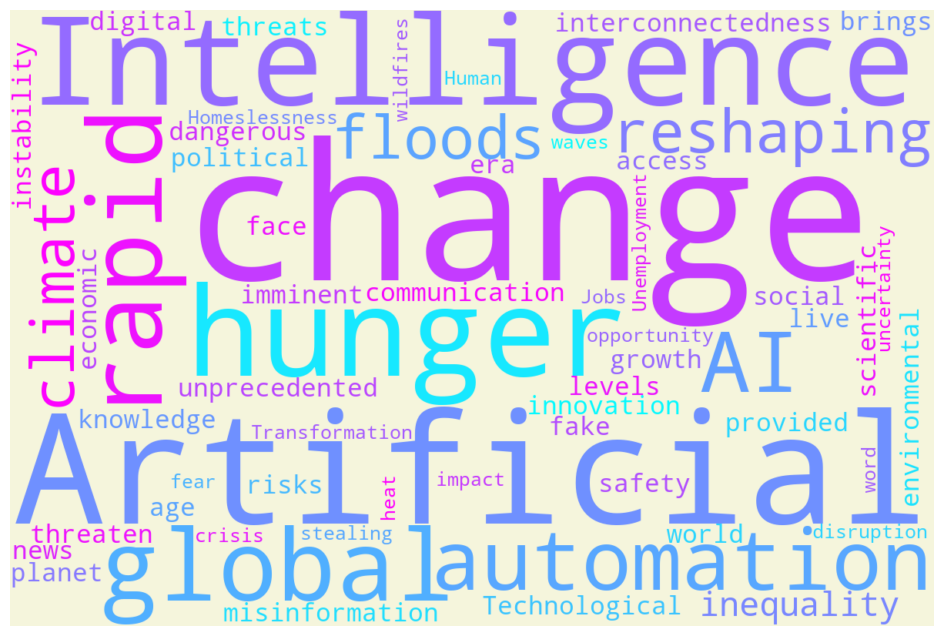

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """
We live in an era of rapid change. Technological and scientific growth has provided unprecedented levels of access to knowledge,
global communication, and interconnectedness. However, we face dangerous misinformation, fake news, imminent threats to safety,
and risks of economic, environmental, social, and political instability. Artificial Intelligence, automation, and AI are reshaping
our world, while climate change, floods, hunger, and inequality threaten our planet. The digital age brings innovation, opportunity,
but also fear, uncertainty, and disruption. Rapid change. Transformation. Human impact. Global crisis.
Artificial Intelligence, automation, and AI are reshaping
Climate Change
Floods
Hunger
Inequality 
Homeslessness
Artificial Intelligence stealing Jobs
Unemployment
word hunger
heat waves
wildfires
"""

wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color="beige",
    colormap="cool",
    collocations=False,
    max_words=150
).generate(text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
